<a href="https://colab.research.google.com/github/sushilrughwani/var-models-backtesting/blob/main/VaR_Modeling_and_Backtesting%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective: Compare multiple VaR models for a diversified portfolio

Dataset: Daily ETF prices (2012–2025)

Models: Parametric, Historical, EWMA, Student-t

Validation: Kupiec, Christoffersen, Basel traffic light

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
tickers = [
    "SPY","VGK","VWO",
    "TLT","TIP",
    "USO","UNG","DBA",
    "UUP","GLD"
]
prices = yf.download(tickers,period='15y',auto_adjust=False)['Adj Close']

[*********************100%***********************]  10 of 10 completed


In [3]:
prices = prices.dropna().sort_index()

In [4]:
ar_ret = prices.pct_change().dropna()
log_ret = np.log(1+ar_ret)
log_ret

Ticker,DBA,GLD,SPY,TIP,TLT,UNG,USO,UUP,VGK,VWO
Date,,,,,,,,,,
2011-03-08,-0.000283,-0.002580,0.008712,0.000644,-0.006114,-0.015385,-0.001417,0.004543,0.002509,0.011045
2011-03-09,-0.005972,0.000359,-0.001434,0.001381,0.009655,0.014430,-0.006164,-0.001815,-0.000193,0.000211
2011-03-10,-0.025713,-0.011834,-0.018680,0.005685,0.016646,-0.024167,-0.015578,0.007691,-0.025382,-0.028056
2011-03-11,-0.005282,0.003261,0.006903,-0.001647,-0.005664,0.017459,-0.017299,-0.007237,0.006700,0.007142
2011-03-14,-0.009162,0.004620,-0.006056,0.001465,-0.000437,0.001921,0.005392,-0.005006,-0.005514,0.007520
...,...,...,...,...,...,...,...,...,...,...
2026-03-02,-0.001154,0.012837,0.000568,-0.002775,-0.010093,0.040822,0.061980,0.009190,-0.021296,-0.014913
2026-03-03,0.001154,-0.045638,-0.008853,-0.000628,-0.002011,0.023065,0.033940,0.004745,-0.030598,-0.035747
2026-03-04,0.003836,0.007788,0.007031,-0.002245,-0.003136,-0.041569,0.014965,-0.001822,0.011382,0.006317


In [5]:
w = np.array([0.20 , 0.10  , 0.10, 0.15 ,  0.10 , 0.08 , 0.05 ,  0.07 ,  0.05 , 0.10])
w

array([0.2 , 0.1 , 0.1 , 0.15, 0.1 , 0.08, 0.05, 0.07, 0.05, 0.1 ])

In [6]:
pf_ret = (log_ret.to_numpy() @ w)
pf_ret

array([ 2.88196699e-04,  6.01337327e-04, -1.19251291e-02, ...,
        9.47263595e-05,  2.17826246e-03,  1.19461182e-02])

In [7]:
roll_cov =log_ret.rolling(250).cov().dropna()
roll_cov.head(11)
# for each day we got 10*10 cov matrix based on last 250 days ret

Ticker                  DBA       GLD       SPY       TIP       TLT       UNG  \
Date       Ticker                                                               
2012-03-02 DBA     0.000111  0.000033  0.000078 -0.000006 -0.000048  0.000043   
           GLD     0.000033  0.000182  0.000002  0.000016  0.000009  0.000015   
           SPY     0.000078  0.000002  0.000208 -0.000029 -0.000133  0.000034   
           TIP    -0.000006  0.000016 -0.000029  0.000019  0.000039 -0.000008   
           TLT    -0.000048  0.000009 -0.000133  0.000039  0.000164 -0.000042   
           UNG     0.000043  0.000015  0.000034 -0.000008 -0.000042  0.000565   
           USO     0.000129  0.000062  0.000184 -0.000019 -0.000130  0.000091   
           UUP    -0.000028 -0.000019 -0.000054  0.000007  0.000041 -0.000018   
           VGK     0.000129  0.000025  0.000306 -0.000044 -0.000206  0.000036   
           VWO     0.000115  0.000035  0.000261 -0.000031 -0.000173  0.000035   
2012-03-05 DBA     0.000111  0.000033  0.000079 -0.000006 -0.000048  0.000044   

Ticker                  USO       UUP       VGK       VWO  
Date       Ticker                                          
2012-03-02 DBA     0.000129 -0.000028  0.000129  0.000115  
           GLD     0.000062 -0.000019  0.000025  0.000035  
           SPY     0.000184 -0.000054  0.000306  0.000261  
           TIP    -0.000019  0.000007 -0.000044 -0.000031  
           TLT    -0.000130  0.000041 -0.000206 -0.000173  
           UNG     0.000091 -0.000018  0.000036  0.000035  
           USO     0.000401 -0.000058  0.000282  0.000257  
           UUP    -0.000058  0.000033 -0.000104 -0.000078  
           VGK     0.000282 -0.000104  0.000521  0.000410  
           VWO     0.000257 -0.000078  0.000410  0.000390  
2012-03-05 DBA     0.000129 -0.000028  0.000129  0.000115

In [8]:
times = roll_cov.index.get_level_values(0).unique()
pf_var = []
for t in times:
  cov = roll_cov.xs(t,level=0).values
  pf_var.append(w.T @ cov @ w)
pf_var= pd.Series(pf_var,index=times,name='pf_var')
pf_vol = pf_var **0.5
pf_var

,pf_var
Date,
2012-03-02,0.000041
2012-03-05,0.000041
2012-03-06,0.000042
2012-03-07,0.000041
2012-03-08,0.000042
...,...
2026-03-02,0.000038
2026-03-03,0.000038
2026-03-04,0.000038


In [9]:
pf_var= pd.Series(pf_var,index=times,name='pf_var')
pf_vol = pf_var **0.5

In [10]:
pf_ret = pd.Series(pf_ret,index=log_ret.index)
pf_ret = pf_ret.loc[pf_vol.index]
# Now both pf_ret and pf_vol share same dates[index]
pf_ret.index.equals(pf_vol.index)

True

99% Parametric VaR (Rolling 250-day window)

1-day horizon

Mean return assumed = 0



In [11]:
import scipy.stats as st
rolling_param_VaR = st.norm.ppf(0.01,0,1) * pf_vol
rolling_param_VaR.index=rolling_param_VaR.index.shift(1,freq='D').dropna()
rolling_param_VaR.tail(3)

,pf_var
Date,
2026-03-05,-0.014295
2026-03-06,-0.014248
2026-03-07,-0.014336


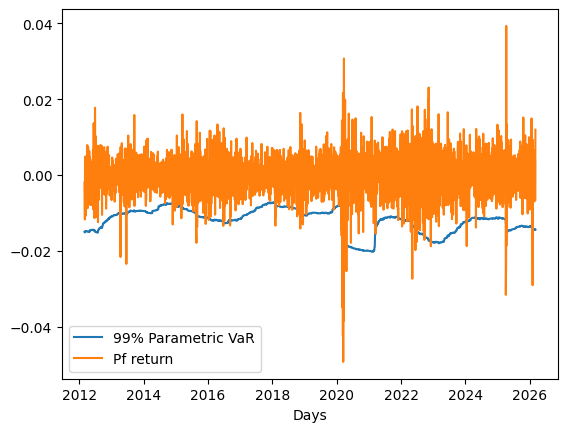

In [12]:
import matplotlib.pyplot as plt
plt.plot(times,rolling_param_VaR,label='99% Parametric VaR')
plt.plot(times,pf_ret,label='Pf return')
plt.xlabel('Days')
plt.legend(loc='lower left')

99% Historical Simulation VaR (Rolling 250-day window)

1-day horizon

Mean return assumed = 0



In [13]:
rolling_hist_VaR = pf_ret.rolling(250).quantile(0.01).dropna()

rolling_hist_VaR.index = rolling_hist_VaR.index.shift(1, freq='D')
rolling_hist_VaR.tail(3)

,0
Date,
2026-03-05,-0.020987
2026-03-06,-0.020987
2026-03-07,-0.020987


In [14]:
print(len(pf_ret))
print(len(rolling_hist_VaR))

3523
3274


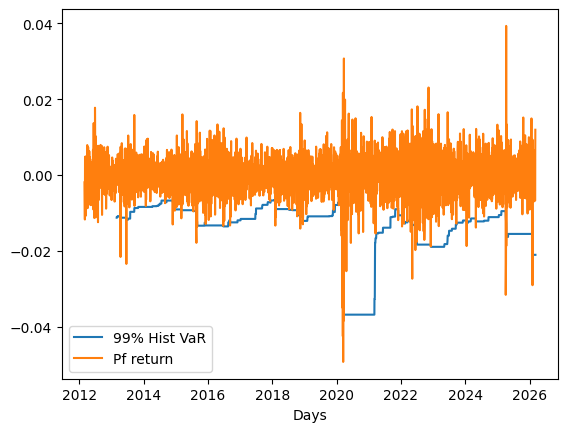

In [15]:
plt.plot(rolling_hist_VaR.index, rolling_hist_VaR, label='99% Hist VaR')
plt.plot(pf_ret.index, pf_ret, label='Pf return')

plt.xlabel('Days')
plt.legend(loc='lower left')
plt.show()

99% EWMA VaR

1-day horizon

Mean return assumed = 0

Lambda[λ] is assumed to be 0.94

Initialized with full portfolio return variance

In [16]:
pf_ret['2026-03-07']=np.nan
pf_ret.tail(2)

,0
Date,
2026-03-06,0.011946
2026-03-07,NaN


In [17]:
lam=0.94  #From JPM Riskmetrics
ewma_variance=[]
ewma_variance=pd.Series(ewma_variance)
ewma_variance[0]=pf_ret.var() #initializing with normal sample variannce
for i in range(1,(len(pf_ret))):
  ewma_variance[i] = ((pf_ret.iloc[i-1]**2)*(1-lam)+(lam*ewma_variance.iloc[i-1]))

In [18]:
ewma_variance.index=pf_ret.index

In [19]:
ewma_variance.tail(2)

,0
Date,
2026-03-06,0.000034
2026-03-07,0.000041


In [20]:
ewma_vol=ewma_variance**0.5
z_for_ewma=st.norm.ppf(0.01,0,1)
ewma_VaR = ewma_vol*z_for_ewma
ewma_VaR.name='VaR'
ewma_VaR.tail(3)

,VaR
Date,
2026-03-05,-0.014021
2026-03-06,-0.013650
2026-03-07,-0.014882


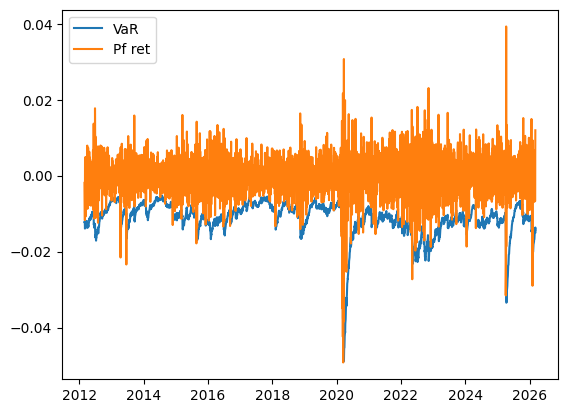

In [21]:
plt.plot(ewma_VaR,label='VaR')
plt.plot(pf_ret, label='Pf ret')
plt.legend()


Aligning all VaR series to the same evaluation window[dates]

In [22]:
ewma_VaR.index

DatetimeIndex(['2012-03-02', '2012-03-05', '2012-03-06', '2012-03-07',
               '2012-03-08', '2012-03-09', '2012-03-12', '2012-03-13',
               '2012-03-14', '2012-03-15',
               ...
               '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27',
               '2026-03-02', '2026-03-03', '2026-03-04', '2026-03-05',
               '2026-03-06', '2026-03-07'],
              dtype='datetime64[ns]', name='Date', length=3524, freq=None)

In [23]:
rolling_hist_VaR = rolling_hist_VaR.reindex(ewma_VaR.index)
rolling_param_VaR=rolling_param_VaR.reindex(rolling_hist_VaR.index)
pf_ret=pf_ret.reindex(rolling_param_VaR.index)
ewma_VaR.index.equals(rolling_hist_VaR.index) ,rolling_param_VaR.index.equals(rolling_hist_VaR.index),rolling_param_VaR.index.equals(pf_ret.index),pf_ret.index.equals(rolling_hist_VaR.index)

(True, True, True, True)

In [24]:
portfolio_risk_df = pd.DataFrame({'pf_ret':pf_ret,'rolling_hist_VaR':rolling_hist_VaR,'ewma_VaR':ewma_VaR,'rolling_param_VaR':rolling_param_VaR})

Exceedance Rate Analysis

In [25]:
portfolio_risk_df['ewma_exceedance']= np.where(portfolio_risk_df['pf_ret']<portfolio_risk_df['ewma_VaR'],1,0)
portfolio_risk_df['hist_exceedance']= np.where(portfolio_risk_df['pf_ret']<portfolio_risk_df['rolling_hist_VaR'],1,0)
portfolio_risk_df['param_exceedance']= np.where(portfolio_risk_df['pf_ret']<portfolio_risk_df['rolling_param_VaR'],1,0)

In [26]:
T = len(portfolio_risk_df)
exp_p = 0.01
exceedance_num = np.array([portfolio_risk_df['param_exceedance'].sum(),portfolio_risk_df['hist_exceedance'].sum(),portfolio_risk_df['ewma_exceedance'].sum()])
exceedance_pct =  exceedance_num/T

In [27]:
exceedance_pct

array([0.0107832 , 0.00908059, 0.01645857])

95% Hyp testing

With:

H₀: true breach probability = 1%

H₁: true breach probability ≠ 1%

In [28]:
z_num = []
for i in range(len(exceedance_num)):
  z_num.append(exceedance_num[i]-(exp_p*T))
z_num=np.array(z_num)
z_den = np.sqrt(exp_p*T*(1-exp_p))
z = z_num/z_den

In [29]:
critical_val_95 = st.norm.ppf(0.975)
# 1 is reject 0 means do not reject
reject_notrej_95 = []
for i in range(len(z)):
  if critical_val_95>abs(z[i]):
    reject_notrej_95.append(0)
  else:
    reject_notrej_95.append(1)

In [30]:
critical_val_90 = st.norm.ppf(0.95)
reject_notrej_90 = []
for i in range(len(z)):
  if critical_val_90>abs(z[i]):
    reject_notrej_90.append(0)
  else:
    reject_notrej_90.append(1)
reject_notrej_90

[0, 0, 1]

In [31]:
z

array([ 0.46727606, -0.54854147,  3.8533345 ])

**Student_t** VaR's

In [32]:
clean_pf_ret=pf_ret.dropna()
df, loc, scale = st.t.fit(clean_pf_ret)
df

np.float64(4.780302626926959)

In [33]:
df_fixed = 5
t_critical = st.t.ppf(0.01, df_fixed)
scale_adj = np.sqrt((df_fixed - 2) / df_fixed)
rolling_t_VaR = t_critical * scale_adj * pf_vol
rolling_t_VaR=rolling_t_VaR.shift(1,freq='D')

In [34]:
portfolio_risk_df['rolling_t_VaR']=rolling_t_VaR
portfolio_risk_df['t_exceedance']= np.where(portfolio_risk_df['pf_ret']<portfolio_risk_df['rolling_t_VaR'],1,0)
p_T = portfolio_risk_df['t_exceedance'].sum()/T
p_T

z_T = (portfolio_risk_df['t_exceedance'].sum()-(0.01*T))/((0.01*T*0.99)**0.5)
if abs(z_T)>critical_val_95:
    print('reject')
    reject_notrej_T_95 = 1
else:
    print(' failed to reject')
    reject_notrej_T_95 = 0


 failed to reject


In [35]:
Model_name  = ['Normal','Hist','EWMA','t-VaR']
exceedance = np.append(exceedance_num,portfolio_risk_df['t_exceedance'].sum())
Failure_rate  = exceedance/T
z_stats =  np.append(z,z_T)
reject_notrej_95=np.array(reject_notrej_95)
Reject_at_5_per = np.where(reject_notrej_95==1,'Reject','Failed to reject')
Reject_at_5_per=np.append(Reject_at_5_per,np.where(reject_notrej_T_95==1,'Reject','Failed to reject'))
Exceedance_table = pd.DataFrame({'Model_name':Model_name,'exceedance':exceedance,"Failure_rate":Failure_rate,'z_stats':z_stats,'Reject_at_5_per':Reject_at_5_per})
Exceedance_table

,Model_name,exceedance,Failure_rate,z_stats,Reject_at_5_per
0,Normal,38,0.010783,0.467276,Failed to reject
1,Hist,32,0.009081,-0.548541,Failed to reject
2,EWMA,58,0.016459,3.853334,Reject
3,t-VaR,24,0.006810,-1.902965,Failed to reject


In [36]:
LR_kup = []
for i in range(len(Exceedance_table)):
  N = (0.99**(T-Exceedance_table['exceedance'].iloc[i]))*(0.01**Exceedance_table['exceedance'].iloc[i])
  p_hat = Exceedance_table['Failure_rate'].iloc[i]
  D = ((1-p_hat)**(T-Exceedance_table['exceedance'].iloc[i]))*(p_hat**Exceedance_table['exceedance'].iloc[i])
  LR_kup.append(-2 * np.log(N/D))

In [37]:
from scipy.stats import chi2
Chi_stat = chi2.ppf(0.95, df=1)
LR_kup = pd.Series(LR_kup)
Rej_Notrej_Kupiec = np.where(LR_kup>Chi_stat,1,0)

In [38]:
Rej_Notrej_YN = np.where(Rej_Notrej_Kupiec==1,'Reject','Failed to reject')
Kupiec_table = pd.DataFrame({'Model_name':Model_name,'exceedance':exceedance,"Failure_rate":Failure_rate,'LR_stat':LR_kup,'Reject_at_5_per':Rej_Notrej_YN})
Kupiec_table

,Model_name,exceedance,Failure_rate,LR_stat,Reject_at_5_per
0,Normal,38,0.010783,0.212915,Failed to reject
1,Hist,32,0.009081,0.310471,Failed to reject
2,EWMA,58,0.016459,12.427106,Reject
3,t-VaR,24,0.006810,4.078031,Reject


In [39]:
# Christoffersen

In [40]:
exceptions = pd.DataFrame({'param_exceedance':portfolio_risk_df['param_exceedance'],'hist_exceedance':portfolio_risk_df['hist_exceedance'],'ewma_exceedance':portfolio_risk_df['ewma_exceedance']})
exceptions['t_exceedance']  = portfolio_risk_df['t_exceedance']
exceptions =  exceptions.dropna()
exceptions_shifted = exceptions.shift(1)
exceptions= exceptions.iloc[1:]
exceptions_shifted = exceptions_shifted.iloc[1:]


In [41]:
N00_ewma = ((exceptions['ewma_exceedance'] == 0) & (exceptions_shifted['ewma_exceedance'] == 0)).sum()
N01_ewma = ((exceptions['ewma_exceedance'] == 1) & (exceptions_shifted['ewma_exceedance'] == 0)).sum()
N10_ewma = ((exceptions['ewma_exceedance'] == 0) & (exceptions_shifted['ewma_exceedance'] == 1)).sum()
N11_ewma = ((exceptions['ewma_exceedance'] == 1) & (exceptions_shifted['ewma_exceedance'] == 1)).sum()

In [42]:
len(exceptions)==(N00_ewma+N01_ewma+N10_ewma+N11_ewma)

np.True_

In [43]:
pi_01_ewma = N01_ewma/(N00_ewma+N01_ewma)
pi_11_ewma = N11_ewma/(N10_ewma+N11_ewma)
print(pi_01_ewma,pi_11_ewma)
# If yesterday breached, today’s breach probability jumps from ~1.5% to ~9.3%.

0.015295815295815297 0.08620689655172414


H₀ (Null): Exceptions are independent
(π₀₁ = π₁₁ = p)

H₁ (Alt): Exceptions follow Markov process
(π₀₁ ≠ π₁₁)

In [44]:
p_hat_ch_ewma = (N01_ewma+N11_ewma)/len(exceptions)
loglik__ind_ewma = (np.log(1-p_hat_ch_ewma)*(N00_ewma+N10_ewma))+(np.log(p_hat_ch_ewma)*(N01_ewma+N11_ewma))
loglik__markov_ewma = (N00_ewma*np.log(1-pi_01_ewma))+(N01_ewma*np.log(pi_01_ewma))+(N10_ewma*np.log(1-pi_11_ewma))+(N11_ewma*np.log(pi_11_ewma))
LR_ind_ewma  = -2*(loglik__ind_ewma-loglik__markov_ewma)
LR_ind_ewma

np.float64(9.058488199644444)

In [45]:
Rej_Notrej_CR = [np.nan,np.nan,np.nan,np.nan]
if LR_ind_ewma>Chi_stat:
  print('Reject')
  Rej_Notrej_CR[2]=1
else:
  print('Failed to reject')
  Rej_Notrej_CR[2]=0

Reject


In [46]:
# Interpretation
# EWMA (λ = 0.94):
# Breaches are statistically clustered.
# Probability of breach is much higher following a breach.
# Model reacts too slowly during volatility spikes.

In [47]:
LR_Conditional_Coverage_ewma  = LR_ind_ewma+LR_kup[2]
Chi_stat_cc = chi2.ppf(0.95, df=2)
Rej_Notrej_CC = [np.nan,np.nan,np.nan,np.nan]

if LR_Conditional_Coverage_ewma>Chi_stat_cc:
  print('reject')
  Rej_Notrej_CC[2]=1
else:
  print('Failed to reject')
  Rej_Notrej_CC[2]=0


reject


In [48]:
Rej_Notrej_CC

[nan, nan, 1, nan]

In [49]:
N00_hist = ((exceptions['hist_exceedance'] == 0) & (exceptions_shifted['hist_exceedance'] == 0)).sum()
N01_hist = ((exceptions['hist_exceedance'] == 1) & (exceptions_shifted['hist_exceedance'] == 0)).sum()
N10_hist = ((exceptions['hist_exceedance'] == 0) & (exceptions_shifted['hist_exceedance'] == 1)).sum()
N11_hist = ((exceptions['hist_exceedance'] == 1) & (exceptions_shifted['hist_exceedance'] == 1)).sum()

pi_01_hist = N01_hist / (N00_hist + N01_hist)
pi_11_hist = N11_hist / (N10_hist + N11_hist)

p_hat_ch_hist = (N01_hist + N11_hist) / len(exceptions)

loglik_ind_hist = (np.log(1 - p_hat_ch_hist) * (N00_hist + N10_hist)) + \
                  (np.log(p_hat_ch_hist) * (N01_hist + N11_hist))

loglik_markov_hist = (N00_hist * np.log(1 - pi_01_hist)) + \
                     (N01_hist * np.log(pi_01_hist)) + \
                     (N10_hist * np.log(1 - pi_11_hist)) + \
                     (N11_hist * np.log(pi_11_hist))

LR_ind_hist = -2 * (loglik_ind_hist - loglik_markov_hist)

if LR_ind_hist > Chi_stat:
   Rej_Notrej_CR[0]=1
   print("Reject")
else:
    Rej_Notrej_CR[0]=0
    print("Failed to reject")

LR_Conditional_Coverage_hist = LR_ind_hist + LR_kup[0]

if LR_Conditional_Coverage_hist > chi2.ppf(0.95, df=2):
    Rej_Notrej_CC[0]=1
    print("Reject")
else:
    Rej_Notrej_CC[0]=0
    print("Failed to reject")

Reject
Reject


In [50]:
N00_param = ((exceptions['param_exceedance'] == 0) & (exceptions_shifted['param_exceedance'] == 0)).sum()
N01_param = ((exceptions['param_exceedance'] == 1) & (exceptions_shifted['param_exceedance'] == 0)).sum()
N10_param = ((exceptions['param_exceedance'] == 0) & (exceptions_shifted['param_exceedance'] == 1)).sum()
N11_param = ((exceptions['param_exceedance'] == 1) & (exceptions_shifted['param_exceedance'] == 1)).sum()

pi_01_param = N01_param / (N00_param + N01_param)
pi_11_param = N11_param / (N10_param + N11_param)

p_hat_ch_param = (N01_param + N11_param) / len(exceptions)

loglik_ind_param = (np.log(1 - p_hat_ch_param) * (N00_param + N10_param)) + \
                   (np.log(p_hat_ch_param) * (N01_param + N11_param))

loglik_markov_param = (N00_param * np.log(1 - pi_01_param)) + \
                      (N01_param * np.log(pi_01_param)) + \
                      (N10_param * np.log(1 - pi_11_param)) + \
                      (N11_param * np.log(pi_11_param))

LR_ind_param = -2 * (loglik_ind_param - loglik_markov_param)

if LR_ind_param > Chi_stat:
    Rej_Notrej_CR[1]=1
    print("Reject")
else:
    Rej_Notrej_CR[1]=0
    print("Failed to reject")

LR_Conditional_Coverage_param = LR_ind_param + LR_kup[1]

if LR_Conditional_Coverage_param > chi2.ppf(0.95, df=2):
    Rej_Notrej_CC[1]=1
    print("Reject")
else:
    Rej_Notrej_CC[1]=0
    print("Failed to reject")

Failed to reject
Failed to reject


In [51]:
Rej_Notrej_CR,Rej_Notrej_CC

([1, 0, 1, nan], [1, 0, 1, nan])

In [52]:
exceptions.sum()

,0
param_exceedance,38
hist_exceedance,32
ewma_exceedance,58
t_exceedance,24


In [53]:
(exceptions.sum()/exceptions.count())*100
# in%

,0
param_exceedance,1.078626
hist_exceedance,0.908317
ewma_exceedance,1.646324
t_exceedance,0.681238


In [54]:
N00_t = ((exceptions['t_exceedance'] == 0) & (exceptions_shifted['t_exceedance'] == 0)).sum()
N01_t = ((exceptions['t_exceedance'] == 1) & (exceptions_shifted['t_exceedance'] == 0)).sum()
N10_t = ((exceptions['t_exceedance'] == 0) & (exceptions_shifted['t_exceedance'] == 1)).sum()
N11_t = ((exceptions['t_exceedance'] == 1) & (exceptions_shifted['t_exceedance'] == 1)).sum()
N11_t/exceptions['t_exceedance'].sum(),N10_t/exceptions['t_exceedance'].sum()


(np.float64(0.041666666666666664), np.float64(0.9583333333333334))

In [55]:
pi_01_t = N01_t / (N00_t + N01_t)
pi_11_t = N11_t / (N10_t + N11_t)
pi_01_t  , pi_11_t


(np.float64(0.006573306659045442), np.float64(0.041666666666666664))

In [56]:
p_hat_ch_t  = (N01_t+N11_t)/len(exceptions)
p_hat_ch_t

np.float64(0.006812375816065853)

In [57]:
loglik_ind_t = (np.log(1 - p_hat_ch_t) * (N00_t + N10_t)) + \
                   (np.log(p_hat_ch_t) * (N01_t + N11_t))


In [58]:
loglik_markov_t = (N00_t * np.log(1 - pi_01_t)) + \
                  (N01_t * np.log(pi_01_t)) + \
                  (N10_t * np.log(1 - pi_11_t)) + \
                  (N11_t * np.log(pi_11_t))

In [59]:
LR_ind_t = -2 * (loglik_ind_t - loglik_markov_t)
LR_ind_t

np.float64(2.0085269167629463)

In [60]:
if LR_ind_t > Chi_stat:
    Rej_Notrej_CR[3]=1
    print("Reject")
else:
    Rej_Notrej_CR[3]=0
    print("Failed to reject")


Failed to reject


In [61]:
LR_Conditional_Coverage_t = LR_ind_t + LR_kup[3]

if LR_Conditional_Coverage_t > chi2.ppf(0.95, df=2):
    Rej_Notrej_CC[3] = 1
    print("Reject")
else:
    Rej_Notrej_CC[3] = 0
    print("Failed to reject")


Reject


Basel’s Traffic Light Backtesting

In [62]:
tot_exceptions_250 = exceptions.iloc[-250:].sum()

zone = []
for val in tot_exceptions_250:
    if val <= 4:
        zone.append("Green")
    elif val <= 9:
        zone.append("Yellow")
    else:
        zone.append("Red")

In [63]:
Basel_Zone=pd.DataFrame({
    "Exceptions": tot_exceptions_250,
    "Basel Zone": zone
})
Basel_Zone

,Exceptions,Basel Zone
param_exceedance,2,Green
hist_exceedance,3,Green
ewma_exceedance,5,Yellow
t_exceedance,2,Green


In [64]:
stress_ret=pf_ret.loc['2020-02-15':'2020-06-15']
stress_var=portfolio_risk_df.loc['2020-02-15':'2020-06-15'].iloc[:,1:4]
stress_ret.index.equals(stress_var.index)
stress_var.head(2)
stress_var['t_var']=portfolio_risk_df['rolling_t_VaR'].loc['2020-02-15':'2020-06-15']
stress_var.head(3)

,rolling_hist_VaR,ewma_VaR,rolling_param_VaR,t_var
Date,,,,
2020-02-18,NaN,-0.007520,NaN,NaN
2020-02-19,-0.00701,-0.008412,-0.008037,-0.009005
2020-02-20,-0.00701,-0.008488,-0.008055,-0.009025


In [65]:
stress_exceedance = []
for i in range(4):
    stress_exceedance.append((np.where(stress_ret.values < stress_var.iloc[:, i].values, 1, 0)).sum() / stress_ret.values.shape[0])

In [66]:
stress_exceedance_per=stress_exceedance*np.repeat(100,4)
stress_exceedance_per

array([7.22891566, 8.43373494, 9.63855422, 6.02409639])

Reporting


In [67]:
var_models = ['rolling_hist_VaR','ewma_VaR',	'rolling_param_VaR'	,'t_var']
summary_table = pd.DataFrame(stress_exceedance,index=var_models)
summary_table.columns=['COVID period stress exceedance']
summary_table[['Exceedance failure rate','Exceedance at 5%']]=\
Exceedance_table[['Failure_rate','Reject_at_5_per']].values

In [68]:
summary_table[['Kupiec likelihood ratio','Kupiec at 5%']]=\
Kupiec_table[['LR_stat','Reject_at_5_per']].values

In [69]:
Christoffersen_independence_test=np.where(np.array(Rej_Notrej_CR)==1,'reject','failed to reject')
Conditional_coverage_test=np.where(np.array(Rej_Notrej_CC)==1,'reject','failed to reject')

In [70]:
summary_table['Christoffersen independence test']=Christoffersen_independence_test
summary_table['Conditional coverage test']=Conditional_coverage_test

In [71]:
summary_table['Basel traffic light']=Basel_Zone["Basel Zone"].values

In [72]:
summary_table
# t VaR captures fat tails better but none of these models capture vol clustering

,COVID period stress exceedance,Exceedance failure rate,Exceedance at 5%,Kupiec likelihood ratio,Kupiec at 5%,Christoffersen independence test,Conditional coverage test,Basel traffic light
rolling_hist_VaR,0.072289,0.010783,Failed to reject,0.212915,Failed to reject,reject,reject,Green
ewma_VaR,0.084337,0.009081,Failed to reject,0.310471,Failed to reject,failed to reject,failed to reject,Green
rolling_param_VaR,0.096386,0.016459,Reject,12.427106,Reject,reject,reject,Yellow
t_var,0.060241,0.00681,Failed to reject,4.078031,Reject,failed to reject,reject,Green


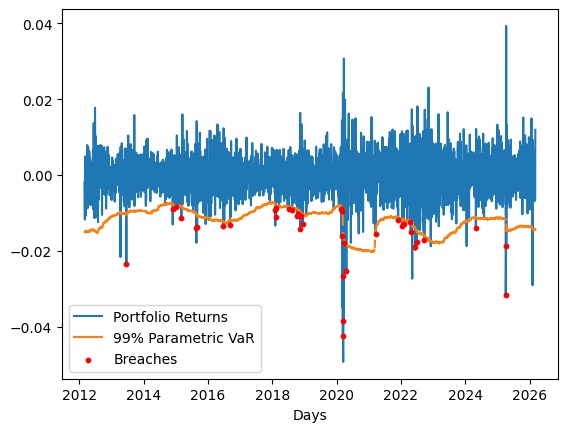

In [73]:
breach_points = pf_ret.loc[exceptions.index][exceptions['param_exceedance'] == 1]

plt.plot(pf_ret.index, pf_ret, label='Portfolio Returns')
plt.plot(rolling_param_VaR.index, rolling_param_VaR, label='99% Parametric VaR')

plt.scatter(breach_points.index, breach_points,
            color='red', s=10, label='Breaches', zorder=3)
plt.xlabel('Days')
plt.legend(loc='lower left')
plt.show()

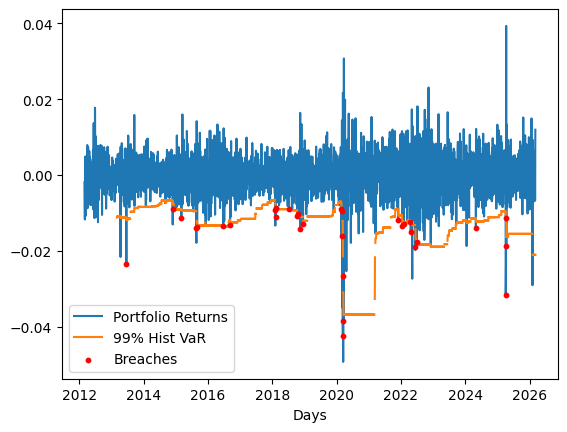

In [74]:
breach_points_2 = pf_ret.loc[exceptions.index][exceptions['hist_exceedance'] == 1]

plt.plot(pf_ret.index, pf_ret, label='Portfolio Returns')
plt.plot(rolling_hist_VaR.index, rolling_hist_VaR, label='99% Hist VaR')

plt.scatter(breach_points_2.index, breach_points_2,
            color='red', s=10, label='Breaches', zorder=3)

plt.xlabel('Days')
plt.legend(loc='lower left')
plt.show()

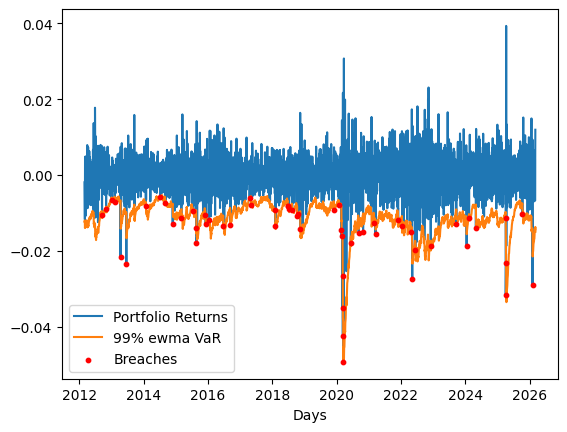

In [75]:
breach_points_3 = pf_ret.loc[exceptions.index][exceptions['ewma_exceedance'] == 1]

plt.plot(pf_ret.index, pf_ret, label='Portfolio Returns')
plt.plot(ewma_VaR.index, ewma_VaR, label='99% ewma VaR')

plt.scatter(breach_points_3.index, breach_points_3,
            color='red', s=10, label='Breaches', zorder=3)

plt.xlabel('Days')
plt.legend(loc='lower left')
plt.show()

In [76]:
# stress-period comparison table
stress_comparision = pd.DataFrame(stress_exceedance_per,index=exceptions.columns,columns=['Stress-Period VaR exceedance (%)'])
stress_comparision['Overall VaR exceedance (%)']=(exceedance/T)*100
stress_comparision

,Stress-Period VaR exceedance (%),Overall VaR exceedance (%)
param_exceedance,7.228916,1.078320
hist_exceedance,8.433735,0.908059
ewma_exceedance,9.638554,1.645857
t_exceedance,6.024096,0.681044
